# Watt's the Cost — Model Comparison
### Julia Craciun

**This notebook generates and compares the results of the following models:**
1. Global mean baseline
2. `rate_type_index`-only baseline
3. Categorical-only linear model (`rate_type_index` + `ownership` + `service_type`)
4. Linear model, all features, **no VIF pruning**
5. Linear model, all features, **with VIF pruning** (for comparison — see Section 9 for why this loses accuracy despite "fixing" collinearity)
6. Linear model, all features, **L2-regularized** (an alternative to VIF for taming collinearity without deleting columns)
7. Small neural network, all features
8. Larger neural network, all features

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf

# set a seed for reproducibility 
SEED = 0
tf.random.set_seed(SEED)
pd.set_option('display.max_columns', 50)


## 2. Load Data

In [ ]:
df = pd.read_parquet('data/cleaned_data.parquet', engine='pyarrow')
print(f'Shape: {df.shape}')

y = df['rate'].copy()
X = df.drop(columns=['rate']).copy()
zip_groups = df['zip'].copy() # keep before zip gets dropped from X, needed for the group split


Shape: (166987, 106)


## 3. Preprocessing

In [ ]:
# basic column type fixes 
X = X.drop(columns=['zip'])
X['rate_type_index'] = X['rate_type_index'].astype(str)

utility_cols = ['Utility Res Sales MWh', 'Utility Com Sales MWh', 'Utility Ind Sales MWh']
X[utility_cols] = X[utility_cols].apply(pd.to_numeric, errors='coerce')

# generate a feature column for if row was originall missing data 
for c in utility_cols:
    X[c + '_was_missing'] = X[c].isna().astype(int)


In [ ]:
# drop columns with zero variance 
num_cols_all = X.select_dtypes(include=[np.number]).columns
zero_var_cols = [c for c in num_cols_all if X[c].std() == 0 or X[c].nunique() <= 1]
print('Dropping zero-variance columns:', zero_var_cols)
X = X.drop(columns=zero_var_cols)


Dropping zero-variance columns: ['Non-Base Regional Nuclear Pct', 'Non-Base Regional Hydroelectric Pct', 'Non-Base Regional Wind Pct', 'Non-Base Regional Solar Pct', 'Non-Base Regional Geothermal Pct']


In [ ]:
# log transform columns that are zero inflated or are skewed
est_cols = [c for c in [
    'est', 'n<5', 'n5_9', 'n10_19', 'n20_49',
    'n50_99', 'n100_249', 'n250_499', 'n500_999', 'n1000',
] if c in X.columns]

zero_inflated_volume_cols = [c for c in utility_cols + ['Utility Total_Generation_MWh'] if c in X.columns]
plain_volume_cols = [c for c in ['total_population', 'households'] if c in X.columns]

for c in zero_inflated_volume_cols:
    X[c + '_is_zero'] = (X[c] == 0).astype(int)

log_candidates = est_cols + zero_inflated_volume_cols + plain_volume_cols
X[log_candidates] = np.log1p(X[log_candidates].clip(lower=0))


In [ ]:
# convert race counts to population shares
race_cols = [c for c in X.columns if c in (
    'white_alone', 'black_or_african_american_alone',
    'american_indian_and_alaska_native_alone', 'asian_alone',
    'native_hawaiian_and_other_pacific_islander_alone',
    'some_other_race_alone', 'two_or_more_races:',
    'two_or_more_races:_two_races_including_some_other_race',
    'two_or_more_races:_two_races_excluding_some_other_race,_and_three_or_more_races',
)]
# drop total population and one race reference category
for c in race_cols:
    X[c] = X[c] / X['total_population'].replace(0, np.nan)
X = X.drop(columns=['total_population', 'some_other_race_alone'])

# identify regional and utility energy mix percentage columns
regional_pct_cols = [c for c in X.columns if 'Regional' in c and 'Non-Base' not in c]
nonbase_pct_cols  = [c for c in X.columns if 'Non-Base Regional' in c]
gen_pct_cols      = [c for c in X.columns if c.startswith('Utility ') and c.endswith('_Pct')]

# drop one reference category from each percentage group
reference_cols_to_drop = [c for c in [
    sorted(regional_pct_cols)[0] if regional_pct_cols else None,
    sorted(nonbase_pct_cols)[0] if nonbase_pct_cols else None,
    sorted(gen_pct_cols)[0] if gen_pct_cols else None,
] if c is not None]
X = X.drop(columns=reference_cols_to_drop)

# identify income bracket variables
income_bracket_cols = [c for c in X.columns
                        if c.startswith('households_') and 'median' not in c
                        and 'mean' not in c and 'percent_allocated' not in c]
# drop one income bracket as the reference category
if income_bracket_cols:
    X = X.drop(columns=[sorted(income_bracket_cols)[0]])

print(f'Columns after preprocessing: {X.shape[1]}')


Columns after preprocessing: 100


## 4. Optional: VIF Pruning

Method for removing correlated variables (affects linear regression model interpretability).

In [7]:
def fast_vif(df_numeric, thresh=10.0, sample_size=30000, random_state=0):
    data = df_numeric
    if len(data) > sample_size:
        data = data.sample(sample_size, random_state=random_state)
    cols = data.columns.tolist()
    while len(cols) > 1:
        corr = data[cols].corr()
        bad_cols = corr.columns[corr.isna().any()].tolist()
        if bad_cols:
            cols = [c for c in cols if c not in bad_cols]
            continue
        vifs = np.diag(np.linalg.pinv(corr.values))
        max_vif = vifs.max()
        if max_vif < thresh:
            break
        drop_col = cols[np.argmax(vifs)]
        cols.remove(drop_col)
    return cols


num_cols_candidate = X.select_dtypes(include=[np.number]).columns.tolist()
vif_keep_cols = fast_vif(X[num_cols_candidate], thresh=10.0)
vif_drop_cols = [c for c in num_cols_candidate if c not in vif_keep_cols]
print(f'VIF would drop {len(vif_drop_cols)} / {len(num_cols_candidate)} numeric columns')


VIF would drop 97 / 97 numeric columns


## 5. Train / Val / Test Split — Grouped by ZIP

Prevents the same ZIP from appearing in both train and test, which would otherwise let the model partly memorize ZIP-level features rather than generalize from them.

In [8]:
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(gss1.split(X, y, groups=zip_groups))
X_train, X_temp = X.iloc[train_idx].copy(), X.iloc[temp_idx].copy()
y_train, y_temp = y.iloc[train_idx].copy(), y.iloc[temp_idx].copy()
zip_temp = zip_groups.iloc[temp_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_idx, test_idx = next(gss2.split(X_temp, y_temp, groups=zip_temp))
X_val, X_test = X_temp.iloc[val_idx].copy(), X_temp.iloc[test_idx].copy()
y_val, y_test = y_temp.iloc[val_idx].copy(), y_temp.iloc[test_idx].copy()

train_zips = set(zip_groups.iloc[train_idx])
val_zips   = set(zip_groups.iloc[temp_idx].iloc[val_idx])
test_zips  = set(zip_groups.iloc[temp_idx].iloc[test_idx])
assert not (train_zips & val_zips) and not (train_zips & test_zips) and not (val_zips & test_zips)
print('No ZIP overlap between splits - confirmed.')

utility_cols_present = [c for c in utility_cols if c in X_train.columns]
utility_medians = X_train[utility_cols_present].median()
for split in (X_train, X_val, X_test):
    split[utility_cols_present] = split[utility_cols_present].fillna(utility_medians)

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')


No ZIP overlap between splits - confirmed.
Train: (116731, 100)  Val: (25070, 100)  Test: (25186, 100)


## 6. Train + Evaluate Helper Functions

In [9]:
def train_and_evaluate(name, feature_cols, cat_cols, num_cols, build_fn,
                        learning_rate=0.01, max_epochs=200, batch_size=2048, patience=8):
    print(f'=== {name} ===')
    start = time.time()

    preprocessor = ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', StandardScaler(), num_cols),
    ]) if num_cols else ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols),
    ])

    Xtr = preprocessor.fit_transform(X_train[feature_cols])
    Xv  = preprocessor.transform(X_val[feature_cols])
    Xte = preprocessor.transform(X_test[feature_cols])

    model = build_fn(Xtr.shape[1], learning_rate)
    callback = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=patience, restore_best_weights=True)

    fit = model.fit(Xtr, y_train, epochs=max_epochs, batch_size=batch_size,
                     validation_data=(Xv, y_val), verbose=0, callbacks=[callback])

    elapsed = time.time() - start
    epochs_run = len(fit.history['loss'])

    # train/val loss curve
    plt.figure(figsize=(6, 3))
    plt.plot(fit.history['loss'], label='train')
    plt.plot(fit.history['val_loss'], label='val')
    plt.xlabel('epoch'); plt.ylabel('MSE loss')
    plt.title(f'{name} — {epochs_run} epochs, {elapsed:.1f}s')
    plt.legend()
    plt.show()

    preds_val  = model.predict(Xv, verbose=0).flatten()
    preds_test = model.predict(Xte, verbose=0).flatten()
    preds_train = model.predict(Xtr, verbose=0).flatten()

    result = {
        'model': name,
        'n_features': Xtr.shape[1],
        'epochs_run': epochs_run,
        'seconds': round(elapsed, 1),
        'train_rmse': np.sqrt(mean_squared_error(y_train, preds_train)),
        'train_mae': mean_absolute_error(y_train, preds_train),
        'val_rmse':  np.sqrt(mean_squared_error(y_val, preds_val)),
        'val_mae':   mean_absolute_error(y_val, preds_val),
        'test_rmse': np.sqrt(mean_squared_error(y_test, preds_test)),
        'test_mae':  mean_absolute_error(y_test, preds_test),
    }
    print(result)
    return result


## 7. Model Builders

In [10]:
def build_linear(num_features, learning_rate):
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    model = tf.keras.Sequential([tf.keras.layers.Dense(1, input_shape=(num_features,))])
    model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate),
                   loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')])
    return model


def build_linear_l2(num_features, learning_rate, l2=0.01):
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    model = tf.keras.Sequential([tf.keras.layers.Dense(
        1, input_shape=(num_features,), kernel_regularizer=tf.keras.regularizers.l2(l2))])
    model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate),
                   loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')])
    return model


def build_nn(num_features, learning_rate, hidden_units=(64, 32), clipnorm=1.0):
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    model = tf.keras.Sequential([tf.keras.layers.Input(shape=(num_features,))])
    for units in hidden_units:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
    model.add(tf.keras.layers.Dense(1))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')])
    return model


## 8. Run Every Model

In [ ]:
results = []

# baseline 1: global mean
train_mean = y_train.mean()
train_preds_mean = np.full(len(y_train), train_mean)
results.append({
    'model': '1. Global mean', 'n_features': 0, 'epochs_run': 0, 'seconds': 0.0,
    'train_rmse': np.sqrt(mean_squared_error(y_train, train_preds_mean)),
    'train_mae': mean_absolute_error(y_train, train_preds_mean),
    'val_rmse':  np.sqrt(mean_squared_error(y_val, np.full(len(y_val), train_mean))),
    'val_mae':   mean_absolute_error(y_val, np.full(len(y_val), train_mean)),
    'test_rmse': np.sqrt(mean_squared_error(y_test, np.full(len(y_test), train_mean))),
    'test_mae':  mean_absolute_error(y_test, np.full(len(y_test), train_mean)),
})

# baseline 2: rate_type_index only
rate_type_train_means = y_train.groupby(X_train['rate_type_index']).mean()
preds_val_rt  = X_val['rate_type_index'].map(rate_type_train_means)
preds_test_rt = X_test['rate_type_index'].map(rate_type_train_means)
preds_train_rt = X_train['rate_type_index'].map(rate_type_train_means)

results.append({
    'model': '2. rate_type_index only', 'n_features': 1, 'epochs_run': 0, 'seconds': 0.0,
    'train_rmse': np.sqrt(mean_squared_error(y_train, preds_train_rt)),
    'train_mae': mean_absolute_error(y_train, preds_train_rt),
    'val_rmse':  np.sqrt(mean_squared_error(y_val, preds_val_rt)),
    'val_mae':   mean_absolute_error(y_val, preds_val_rt),
    'test_rmse': np.sqrt(mean_squared_error(y_test, preds_test_rt)),
    'test_mae':  mean_absolute_error(y_test, preds_test_rt),
})

print(results[0])
print(results[1])


{'model': '1. Global mean', 'n_features': 0, 'epochs_run': 0, 'seconds': 0.0, 'train_rmse': 0.07357653522684046, 'train_mae': 0.052125547936363696, 'val_rmse': 0.07401180483871388, 'val_mae': 0.05275744068655416, 'test_rmse': 0.07196765567458586, 'test_mae': 0.05101421854604842}
{'model': '2. rate_type_index only', 'n_features': 1, 'epochs_run': 0, 'seconds': 0.0, 'train_rmse': 0.06657524607362235, 'train_mae': 0.043438013977531054, 'val_rmse': 0.06696613230012814, 'val_mae': 0.04384427768519714, 'test_rmse': 0.06486359020741436, 'test_mae': 0.04252004178383135}


=== 3. Categorical-only ===


/var/folders/6v/rg4h3frn3w925jp6lfvf1vmc0000gn/T/ipykernel_2527/996199341.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  all_cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
/opt/miniconda3/envs/tf_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-08-04 20:37:31.7189

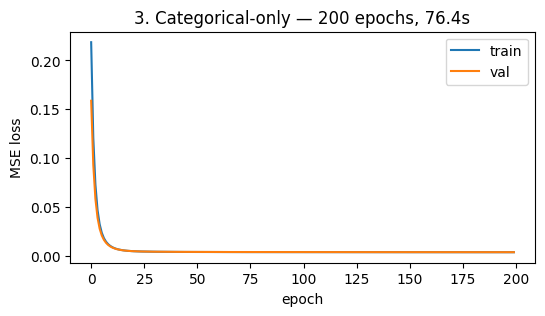

{'model': '3. Categorical-only', 'n_features': 8, 'epochs_run': 200, 'seconds': 76.4, 'train_rmse': 0.06180518872905965, 'train_mae': 0.04211427845773339, 'val_rmse': 0.06204279016551075, 'val_mae': 0.04211823431904313, 'test_rmse': 0.06032931996465204, 'test_mae': 0.04123712151422974}


In [ ]:
all_cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
all_num_cols = [c for c in X.columns if c not in all_cat_cols]
vif_num_cols = [c for c in all_num_cols if c in vif_keep_cols]

# model 3: categorical-only
results.append(train_and_evaluate(
    '3. Categorical-only', ['rate_type_index', 'ownership', 'service_type'],
    cat_cols=['rate_type_index', 'ownership', 'service_type'], num_cols=[],
    build_fn=build_linear, learning_rate=0.01,
))


=== 4. All features, no VIF ===


/opt/miniconda3/envs/tf_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


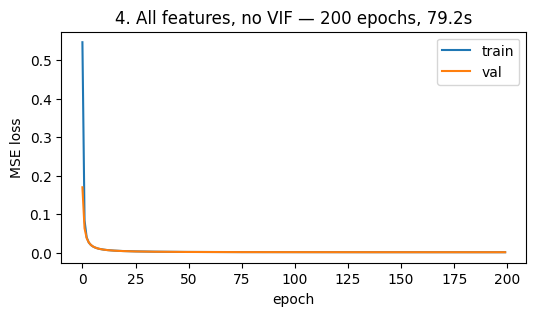

{'model': '4. All features, no VIF', 'n_features': 105, 'epochs_run': 200, 'seconds': 79.2, 'train_rmse': 0.03331586307077815, 'train_mae': 0.024143033910385456, 'val_rmse': 0.03309112145517551, 'val_mae': 0.02387451946852126, 'test_rmse': 0.03241243050027474, 'test_mae': 0.023365796185784077}


In [ ]:
# model 4: all features, no VIF 
results.append(train_and_evaluate(
    '4. All features, no VIF', all_cat_cols + all_num_cols,
    cat_cols=all_cat_cols, num_cols=all_num_cols,
    build_fn=build_linear, learning_rate=0.01,
))


=== 5. All features, with VIF ===


/opt/miniconda3/envs/tf_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


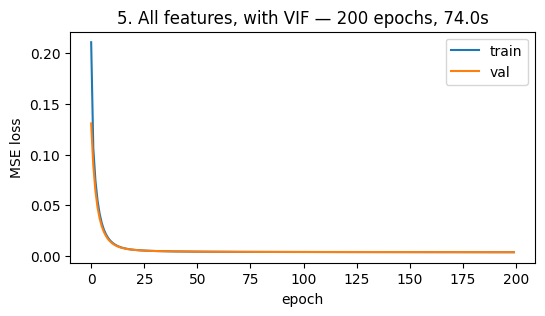

{'model': '5. All features, with VIF', 'n_features': 8, 'epochs_run': 200, 'seconds': 74.0, 'train_rmse': 0.06288679031364093, 'train_mae': 0.04282502693904561, 'val_rmse': 0.06328423000777648, 'val_mae': 0.04279397120490793, 'test_rmse': 0.061512257964355936, 'test_mae': 0.04197961379525143}


In [ ]:
# model 5: all features, WITH VIF pruning (for comparison)
results.append(train_and_evaluate(
    '5. All features, with VIF', all_cat_cols + vif_num_cols,
    cat_cols=all_cat_cols, num_cols=vif_num_cols,
    build_fn=build_linear, learning_rate=0.01,
))


=== 6. All features, L2-regularized ===


/opt/miniconda3/envs/tf_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


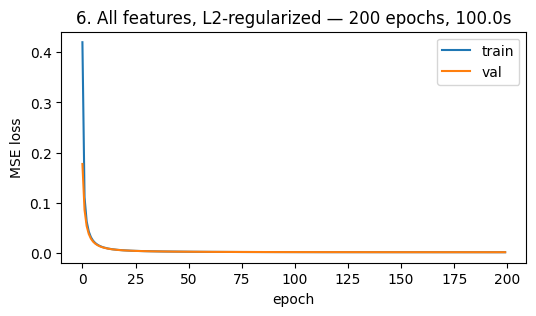

{'model': '6. All features, L2-regularized', 'n_features': 105, 'epochs_run': 200, 'seconds': 100.0, 'train_rmse': 0.03250370145313488, 'train_mae': 0.02311625428890586, 'val_rmse': 0.03279374218942878, 'val_mae': 0.023131714674949497, 'test_rmse': 0.031493605211143, 'test_mae': 0.02233147195104063}


In [ ]:
# model 6: all features, L2-regularized (alternative to VIF)
results.append(train_and_evaluate(
    '6. All features, L2-regularized', all_cat_cols + all_num_cols,
    cat_cols=all_cat_cols, num_cols=all_num_cols,
    build_fn=build_linear_l2, learning_rate=0.01,
))


=== 7. Small NN (32,16), all features ===


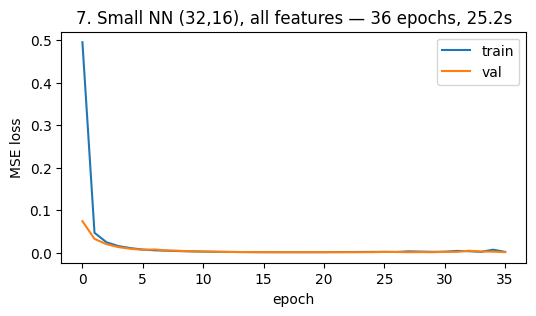

{'model': '7. Small NN (32,16), all features', 'n_features': 105, 'epochs_run': 36, 'seconds': 25.2, 'train_rmse': 0.03400238770335144, 'train_mae': 0.02458655747285597, 'val_rmse': 0.03412807996032079, 'val_mae': 0.024394767465406527, 'test_rmse': 0.032788741492446136, 'test_mae': 0.02370440008346817}


In [ ]:
# model 7: small neural network, all features
results.append(train_and_evaluate(
    '7. Small NN (32,16), all features', all_cat_cols + all_num_cols,
    cat_cols=all_cat_cols, num_cols=all_num_cols,
    build_fn=lambda n, lr: build_nn(n, lr, hidden_units=(32, 16)), learning_rate=0.001,
))


=== 8. Larger NN (128,64,32), all features ===


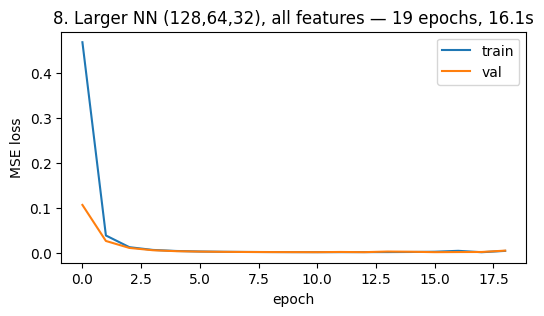

{'model': '8. Larger NN (128,64,32), all features', 'n_features': 105, 'epochs_run': 19, 'seconds': 16.1, 'train_rmse': 0.03681542406430064, 'train_mae': 0.025889991727743332, 'val_rmse': 0.03736714410183274, 'val_mae': 0.025992784022559796, 'test_rmse': 0.035602887841194794, 'test_mae': 0.02520136801665405}


In [ ]:
# model 8: larger neural network, all features
results.append(train_and_evaluate(
    '8. Larger NN (128,64,32), all features', all_cat_cols + all_num_cols,
    cat_cols=all_cat_cols, num_cols=all_num_cols,
    build_fn=lambda n, lr: build_nn(n, lr, hidden_units=(128, 64, 32)), learning_rate=0.0003,
))


## 9. Comparison

Text below generated by Claude for context and result interpretation: 
- **`rate_type_index` alone** captures a real, EDA-consistent chunk of the signal (residential/commercial/industrial have distinct rate distributions).
- **All features (no VIF) should clearly beat categorical-only** — individually-weak numeric predictors (each under ~0.5 correlation with `rate` in the EDA heatmap) combine into meaningfully stronger *joint* predictive power. Weak-alone isn't the same as weak-together.
- **VIF pruning trades accuracy for interpretability, it does not "fix" the model.** Collinearity mainly threatens whether you can trust an *individual* coefficient in isolation ("holding everything else fixed, +1% solar share → X¢"), not the model's overall predictions — correlated features can still combine into accurate predictions as long as the correlation structure is stable between train and test, which it is here (the compositional blocks sum to ~100% by construction). If Model 5 (with VIF) noticeably underperforms Model 4 (without), that's this tradeoff showing up directly, not the VIF code doing something wrong.
- **L2 regularization (Model 6) is offered as a middle ground** — it shrinks correlated coefficients toward each other rather than deleting columns outright, which can give more stable, more trustworthy coefficients without sacrificing the predictive accuracy of using all the features.
- **Neural nets only have room to add value once the input features themselves carry real signal** — on the categorical-only feature set, there's little for extra hidden layers to exploit that a linear model can't already capture; the comparison is more meaningful on the full/all-features set.

In [18]:
comparison = pd.DataFrame(results)
comparison['test_rmse_improvement_vs_global'] = (
    1 - comparison['test_rmse'] / comparison.loc[0, 'test_rmse']
)
comparison


,model,n_features,epochs_run,seconds,train_rmse,train_mae,val_rmse,val_mae,test_rmse,test_mae,test_rmse_improvement_vs_global
0,1. Global mean,0,0,0.0,0.073577,0.052126,0.074012,0.052757,0.071968,0.051014,0.000000
1,2. rate_type_index only,1,0,0.0,0.066575,0.043438,0.066966,0.043844,0.064864,0.042520,0.098712
2,3. Categorical-only,8,200,76.4,0.061805,0.042114,0.062043,0.042118,0.060329,0.041237,0.161716
3,"4. All features, no VIF",105,200,79.2,0.033316,0.024143,0.033091,0.023875,0.032412,0.023366,0.549625
4,"5. All features, with VIF",8,200,74.0,0.062887,0.042825,0.063284,0.042794,0.061512,0.041980,0.145279
5,"6. All features, L2-regularized",105,200,100.0,0.032504,0.023116,0.032794,0.023132,0.031494,0.022331,0.562392
6,"7. Small NN (32,16), all features",105,36,25.2,0.034002,0.024587,0.034128,0.024395,0.032789,0.023704,0.544396
7,"8. Larger NN (128,64,32), all features",105,19,16.1,0.036815,0.025890,0.037367,0.025993,0.035603,0.025201,0.505293


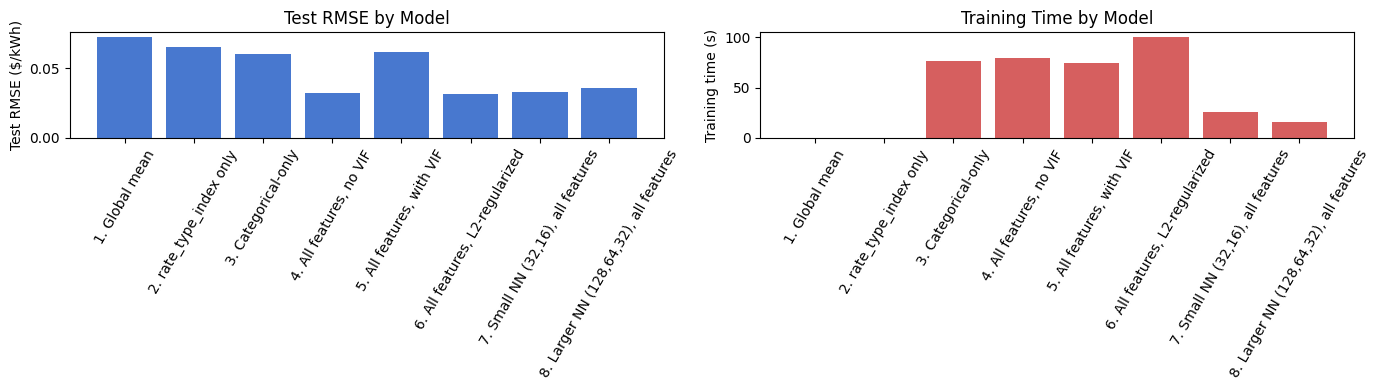

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(comparison['model'], comparison['test_rmse'], color='#4878CF')
axes[0].set_ylabel('Test RMSE ($/kWh)')
axes[0].set_title('Test RMSE by Model')
axes[0].tick_params(axis='x', rotation=60)

axes[1].bar(comparison['model'], comparison['seconds'], color='#D65F5F')
axes[1].set_ylabel('Training time (s)')
axes[1].set_title('Training Time by Model')
axes[1].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()


### Feature importance check (Model 4)

Confirms whether the accuracy gain from adding features lines up with what the EDA flagged, rather than something unexpected driving the result.

In [20]:
final_preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), all_cat_cols),
    ('num', StandardScaler(), all_num_cols),
])
Xtr_final = final_preprocessor.fit_transform(X_train[all_cat_cols + all_num_cols])
final_model = build_linear(Xtr_final.shape[1], 0.01)
final_model.fit(Xtr_final, y_train, epochs=100, batch_size=2048, verbose=0,
                 callbacks=[tf.keras.callbacks.EarlyStopping(monitor='loss', patience=8, restore_best_weights=True)])

weights = final_model.layers[0].get_weights()[0].flatten()
feature_names = final_preprocessor.get_feature_names_out()
pd.Series(weights, index=feature_names).abs().sort_values(ascending=False).head(15)


/opt/miniconda3/envs/tf_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


num__Utility Com Sales MWh_is_zero      0.204027
num__Non-Base Regional Gas Pct          0.149978
num__Non-Base Regional Coal Pct         0.137357
num__Regional Gas Pct                   0.133596
num__Regional Hydroelectric Pct         0.118891
num__Regional Coal Pct                  0.108222
cat__service_type_Delivery              0.106954
num__Regional Nuclear Pct               0.089346
num__Regional Wind Pct                  0.089019
cat__ownership_Investor Owned           0.072222
num__Regional Solar Pct                 0.058971
cat__ownership_Federal                  0.049809
num__moe_two_or_more_races:             0.047861
cat__ownership_Political Subdivision    0.045694
cat__ownership_State                    0.044847
dtype: float32

In [21]:
l2_model = build_linear_l2(Xtr_final.shape[1], 0.01)
l2_model.fit(Xtr_final, y_train, epochs=100, batch_size=2048, verbose=0,
                 callbacks=[tf.keras.callbacks.EarlyStopping(monitor='loss', patience=8, restore_best_weights=True)])

weights_l2 = l2_model.layers[0].get_weights()[0].flatten()
feature_names = final_preprocessor.get_feature_names_out()
pd.Series(weights_l2, index=feature_names).abs().sort_values(ascending=False).head(15)


/opt/miniconda3/envs/tf_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


cat__service_type_Delivery                                         0.096859
num__Utility Com Sales MWh_is_zero                                 0.059047
num__two_or_more_races:                                            0.049430
num__moe_two_or_more_races:                                        0.043521
num__two_or_more_races:_two_races_including_some_other_race        0.040468
num__moe_two_or_more_races:_two_races_including_some_other_race    0.035182
cat__rate_type_index_2                                             0.034849
num__Regional Nuclear Pct                                          0.030696
cat__ownership_Investor Owned                                      0.028394
cat__rate_type_index_1                                             0.026125
num__Non-Base Regional Other Fossil Pct                            0.025566
num__Regional Gas Pct                                              0.024322
num__Regional Wind Pct                                             0.023165
num__Utility